In [22]:
import pandas as pd
df = pd.read_csv('DIVERSITY1.csv')


In [23]:
df.head()

,Stations,Latitude,Longitude,Taxa-Richness,Simpson_1-D,Shannon_H,Pielu'sEvenness_e^H/S,Compartments
0,ST-01,91.944728,21.740218,88,0.9804,4.201,0.7587,1
1,ST-02,91.945152,21.722187,71,0.9817,4.119,0.8663,2
2,ST-03,91.948384,21.706307,81,0.9828,4.221,0.8404,3
3,ST-04,91.954449,21.690443,86,0.9817,4.230,0.7988,4
4,ST-05,91.979893,21.686225,100,0.9859,4.434,0.8423,5


In [24]:
features = ['Taxa-Richness', 'Simpson_1-D', 'Shannon_H', "Pielu'sEvenness_e^H/S"]


In [25]:
X = df[features].values

Graph saved successfully as 'Ecological_Anomaly_Plot.png'


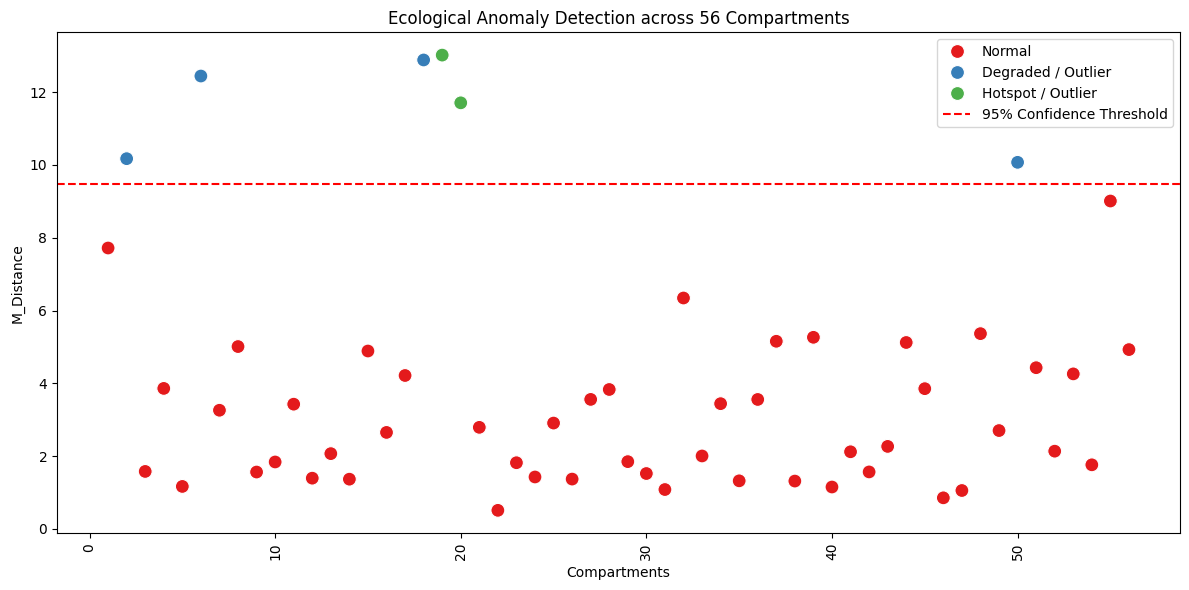

Data results saved successfully as 'Ecological_Anomaly_Results.csv'


In [31]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# [মনে করিয়ে দেওয়া: নিশ্চিত হয়ে নিন আপনার পূর্ববর্তী কোড থেকে 'df' এবং 'features' ভ্যারিয়েবলগুলো লোড করা আছে]
X = df[features].values
covariance_matrix = np.cov(X, rowvar=False)
inv_covariance_matrix = np.linalg.inv(covariance_matrix)
mean_dist = np.mean(X, axis=0)

# Calculate Mahalanobis Distance for each row
vars_minus_mean = X - mean_dist
left_term = np.dot(vars_minus_mean, inv_covariance_matrix)
mahal = np.dot(left_term, vars_minus_mean.T).diagonal()
df['M_Distance'] = mahal

# Calculate Chi-Square P-values (df=4)
df['p_value'] = 1 - stats.chi2.cdf(df['M_Distance'], df=4)

# Classify status
mean_shannon = df['Shannon_H'].mean()
df['Status'] = 'Normal'
df.loc[(df['p_value'] < 0.05) & (df['Shannon_H'] < mean_shannon), 'Status'] = 'Degraded / Outlier'
df.loc[(df['p_value'] < 0.05) & (df['Shannon_H'] >= mean_shannon), 'Status'] = 'Hotspot / Outlier'
 
# Plotting
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Compartments', y='M_Distance', hue='Status', palette='Set1', s=100)
plt.axhline(stats.chi2.ppf(0.95, df=4), color='red', linestyle='--', label='95% Confidence Threshold')
plt.xticks(rotation=90)
plt.title("Ecological Anomaly Detection across 56 Compartments")
plt.legend()
plt.tight_layout()

# ১. প্রথমে ছবিটি কম্পিউটারে সেভ করা (অবশ্যই plt.show() এর আগে)
plt.savefig("Ecological_Anomaly_Plot.png", dpi=300)
print("Graph saved successfully as 'Ecological_Anomaly_Plot.png'")

# ২. তারপর স্ক্রিনে গ্রাফটি প্রদর্শন করা
plt.show()

# ৩. সমস্ত হিসাবনিকাশসহ ডেটাফ্রেমটি নতুন একটি CSV ফাইল হিসেবে সেভ করা
df.to_csv("Ecological_Anomaly_Results.csv", index=False)
print("Data results saved successfully as 'Ecological_Anomaly_Results.csv'")


Graph saved successfully as 'Spearman_Corelation.png'


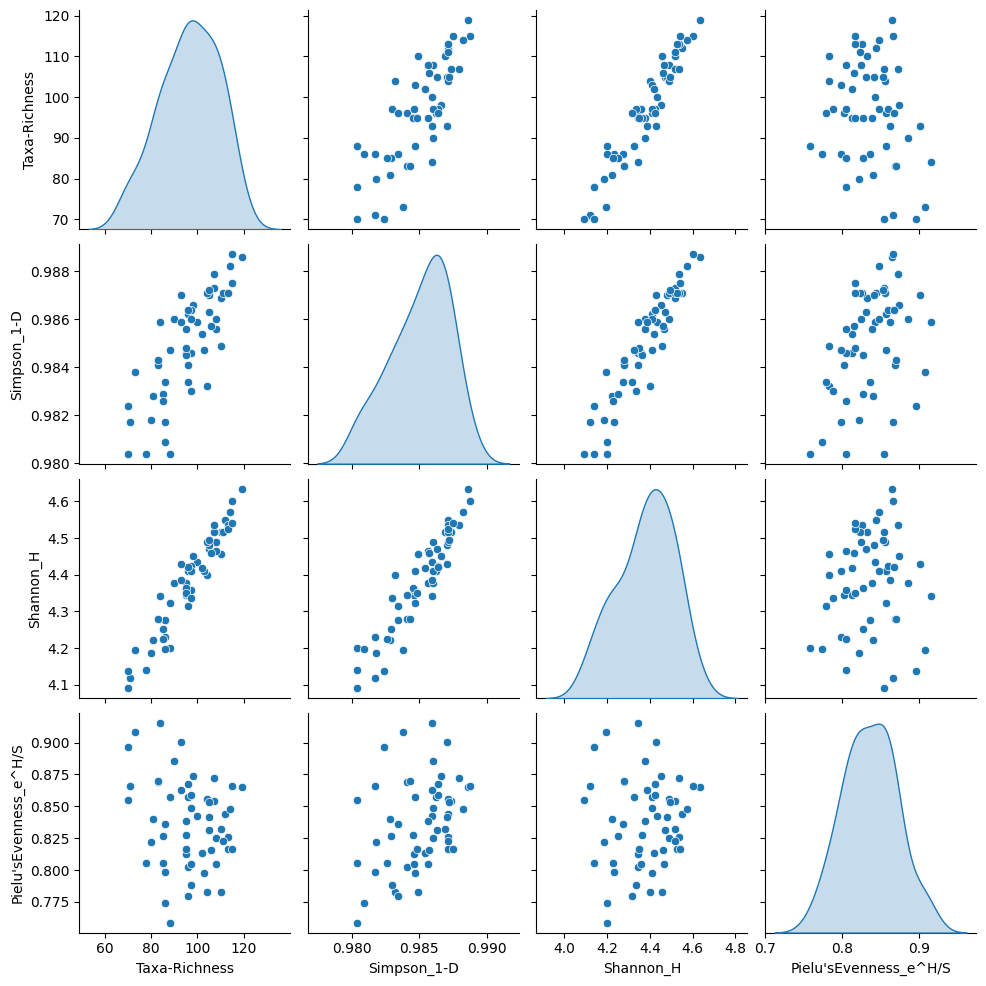


--- Spearman Correlation Matrix ---
                       Taxa-Richness  Simpson_1-D  Shannon_H  \
Taxa-Richness               1.000000     0.802639   0.946928   
Simpson_1-D                 0.802639     1.000000   0.938796   
Shannon_H                   0.946928     0.938796   1.000000   
Pielu'sEvenness_e^H/S      -0.172051     0.378386   0.107560   

                       Pielu'sEvenness_e^H/S  
Taxa-Richness                      -0.172051  
Simpson_1-D                         0.378386  
Shannon_H                           0.107560  
Pielu'sEvenness_e^H/S               1.000000  


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("DIVERSITY1.csv")
features = ['Taxa-Richness', 'Simpson_1-D', 'Shannon_H', "Pielu'sEvenness_e^H/S"]

# 1. Pairplot তৈরি করা এবং একটি ভ্যারিয়েবলে রাখা
plot = sns.pairplot(df[features], diag_kind='kde')

# ২. প্রথমে ছবিটি সেভ করা (এটি সবসময় plt.show() এর আগে থাকতে হবে)
plot.savefig("Spearman_Corelation.png", dpi=300) 
print("Graph saved successfully as 'Spearman_Corelation.png'")

# ৩. তারপর স্ক্রিনে গ্রাফটি দেখানো
plt.show()

# ৪. স্পিয়ারম্যান কোরিলেশন প্রিন্ট করা
print("\n--- Spearman Correlation Matrix ---")
print(df[features].corr(method='spearman'))
